# Notebook 1 — Espacio de Probabilidad

## Diplomado de Técnicas Estadísticas — Módulo II

**Alumno:** Cristopher Carlos García  
**Módulo:** II — Probabilidad y Simulación  
**Tema:** Espacio de Probabilidad  
**Fecha:** Junio 2026

---

En este notebook se desarrollan los fundamentos del **espacio de probabilidad**, partiendo
de las definiciones formales y llegando a simulaciones en Python que ilustran los distintos
enfoques para asignar probabilidades (clásico, frecuentista y geométrico). Cada sección
incluye una explicación teórica seguida de código comentado y sus gráficas correspondientes.


## 0. Librerías utilizadas

Cargamos las librerías que vamos a usar en este notebook. Fijamos una **semilla**
para que las simulaciones sean reproducibles.


In [1]:
# Importamos las librerías necesarias
import numpy as np                 # cálculo numérico y generación de aleatorios
import matplotlib.pyplot as plt    # gráficas
from itertools import product      # productos cartesianos (espacios muestrales)
from fractions import Fraction     # probabilidades como fracciones exactas

# Fijamos la semilla para reproducibilidad de las simulaciones
np.random.seed(42)

# Estilo general de las gráficas
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Definición formal de espacio de probabilidad

Un **espacio de probabilidad** es una terna $(\Omega, \mathcal{F}, P)$ donde:

- $\Omega$ es el **espacio muestral**: el conjunto de todos los resultados posibles de un experimento aleatorio.
- $\mathcal{F}$ es una **$\sigma$-álgebra** de subconjuntos de $\Omega$: la colección de todos los **eventos** a los que podemos asignar probabilidad. Debe cumplir:
  1. $\Omega \in \mathcal{F}$.
  2. Si $A \in \mathcal{F}$, entonces $A^{c} \in \mathcal{F}$ (cerrada bajo complemento).
  3. Si $A_1, A_2, \dots \in \mathcal{F}$, entonces $\bigcup_{i=1}^{\infty} A_i \in \mathcal{F}$ (cerrada bajo uniones numerables).
- $P: \mathcal{F} \to [0,1]$ es una **medida de probabilidad** que asigna a cada evento un número en $[0,1]$.

Cuando $\Omega$ es finito o numerable se suele tomar $\mathcal{F} = 2^{\Omega}$ (el conjunto potencia, es decir, **todos** los subconjuntos de $\Omega$).


## 2. Espacio muestral y eventos

El **espacio muestral** $\Omega$ contiene todos los resultados posibles. Un **evento** es
cualquier subconjunto $A \subseteq \Omega$.

Veamos ejemplos concretos:

- **Lanzar una moneda:** $\Omega = \{A, S\}$ (Águila, Sol).
- **Lanzar un dado:** $\Omega = \{1,2,3,4,5,6\}$.
- **Lanzar dos dados:** $\Omega = \{(i,j): i,j \in \{1,\dots,6\}\}$, con $|\Omega| = 36$.

Además, sobre los eventos podemos aplicar **operaciones de conjuntos**: unión ($A \cup B$),
intersección ($A \cap B$), complemento ($A^{c}$) y diferencia ($A \setminus B$).


In [2]:
# --- Espacio muestral de un dado ---
Omega_dado = set(range(1, 7))
print("Espacio muestral de un dado, Omega =", Omega_dado)

# --- Espacio muestral de dos dados (producto cartesiano) ---
Omega_2dados = set(product(range(1, 7), repeat=2))
print("Número de resultados al lanzar dos dados: |Omega| =", len(Omega_2dados))

# Definimos algunos eventos sobre el dado
A = {n for n in Omega_dado if n % 2 == 0}     # A = 'sale par'
B = {n for n in Omega_dado if n >= 4}          # B = 'sale 4 o más'

print("\nEvento A (par)      =", sorted(A))
print("Evento B (>= 4)     =", sorted(B))

# Operaciones entre eventos
print("\nA union B          =", sorted(A | B))   # unión
print("A interseccion B   =", sorted(A & B))     # intersección
print("Complemento de A   =", sorted(Omega_dado - A))  # complemento
print("A menos B          =", sorted(A - B))     # diferencia

Espacio muestral de un dado, Omega = {1, 2, 3, 4, 5, 6}
Número de resultados al lanzar dos dados: |Omega| = 36

Evento A (par)      = [2, 4, 6]
Evento B (>= 4)     = [4, 5, 6]

A union B          = [2, 4, 5, 6]
A interseccion B   = [4, 6]
Complemento de A   = [1, 3, 5]
A menos B          = [2]


## 3. Axiomas de Kolmogorov

La función de probabilidad $P$ debe satisfacer los tres **axiomas de Kolmogorov**:

1. **No negatividad:** $P(A) \ge 0$ para todo evento $A$.
2. **Normalización:** $P(\Omega) = 1$.
3. **Aditividad numerable:** si $A_1, A_2, \dots$ son eventos **mutuamente excluyentes**
   ($A_i \cap A_j = \varnothing$ para $i \neq j$), entonces
   $$P\!\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i).$$

De estos axiomas se derivan propiedades útiles, por ejemplo:

- $P(A^{c}) = 1 - P(A)$.
- $P(\varnothing) = 0$.
- **Regla de la suma:** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.

Verifiquemos numéricamente la regla de la suma con los eventos $A$ y $B$ del dado (equiprobable).


In [3]:
# Con un dado justo cada resultado tiene probabilidad 1/6.
# Usamos Fraction para obtener probabilidades exactas.
def P(evento, espacio):
    "Probabilidad clásica: casos favorables / casos totales."
    return Fraction(len(evento), len(espacio))

PA = P(A, Omega_dado)
PB = P(B, Omega_dado)
PA_union_B = P(A | B, Omega_dado)
PA_inter_B = P(A & B, Omega_dado)

print("P(A)          =", PA)
print("P(B)          =", PB)
print("P(A n B)      =", PA_inter_B)
print("P(A u B)      =", PA_union_B)

# Verificamos la regla de la suma: P(A u B) = P(A) + P(B) - P(A n B)
suma = PA + PB - PA_inter_B
print("\nP(A)+P(B)-P(A n B) =", suma)
print("¿Se cumple la regla de la suma?", suma == PA_union_B)

# Verificamos la normalización P(Omega) = 1
print("\nP(Omega) =", P(Omega_dado, Omega_dado), "-> axioma de normalización OK")

P(A)          = 1/2
P(B)          = 1/2
P(A n B)      = 1/3
P(A u B)      = 2/3

P(A)+P(B)-P(A n B) = 2/3
¿Se cumple la regla de la suma? True

P(Omega) = 1 -> axioma de normalización OK


## 4. Probabilidad condicional e independencia

La **probabilidad condicional** de $A$ dado $B$ (con $P(B) > 0$) se define como:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

Dos eventos $A$ y $B$ son **independientes** si el ocurrir uno no altera la probabilidad
del otro, lo cual equivale a:
$$P(A \cap B) = P(A)\,P(B) \quad\Longleftrightarrow\quad P(A \mid B) = P(A).$$

**Ejemplo.** En el lanzamiento de un dado, sea $A = \{\text{par}\}$ y $B = \{\ge 4\}$.
Calculemos $P(A \mid B)$ y verifiquemos si son independientes.


In [4]:
# Probabilidad condicional P(A | B) = P(A n B) / P(B)
P_cond = PA_inter_B / PB
print("P(A | B) = P(A n B)/P(B) =", P_cond)

# ¿Son A y B independientes?  Se cumple si P(A n B) == P(A)*P(B)
producto = PA * PB
print("\nP(A n B)   =", PA_inter_B)
print("P(A)*P(B)  =", producto)
print("¿A y B independientes?", PA_inter_B == producto)

# --- Ejemplo de independencia con dos dados ---
# Evento C: 'el primer dado es par';  Evento D: 'el segundo dado es 6'
C = {(i, j) for (i, j) in Omega_2dados if i % 2 == 0}
D = {(i, j) for (i, j) in Omega_2dados if j == 6}
PC = P(C, Omega_2dados)
PD = P(D, Omega_2dados)
PC_inter_D = P(C & D, Omega_2dados)
print("\n--- Dos dados ---")
print("P(C)=", PC, " P(D)=", PD, " P(C n D)=", PC_inter_D, " P(C)*P(D)=", PC*PD)
print("¿C y D independientes?", PC_inter_D == PC * PD)

P(A | B) = P(A n B)/P(B) = 2/3

P(A n B)   = 1/3
P(A)*P(B)  = 1/4
¿A y B independientes? False

--- Dos dados ---
P(C)= 1/2  P(D)= 1/6  P(C n D)= 1/12  P(C)*P(D)= 1/12
¿C y D independientes? True


## 5. Enfoque clásico (Laplace)

En el **enfoque clásico** o de Laplace, cuando todos los resultados de $\Omega$ son
**equiprobables**, la probabilidad de un evento $A$ es:
$$P(A) = \frac{\text{número de casos favorables}}{\text{número de casos totales}} = \frac{|A|}{|\Omega|}.$$

Lo aplicamos a dos experimentos: la **suma de dos dados** y el **reparto de cartas**.


Suma : Probabilidad
   2 : 0.0278
   3 : 0.0556
   4 : 0.0833
   5 : 0.1111
   6 : 0.1389
   7 : 0.1667
   8 : 0.1389
   9 : 0.1111
  10 : 0.0833
  11 : 0.0556
  12 : 0.0278


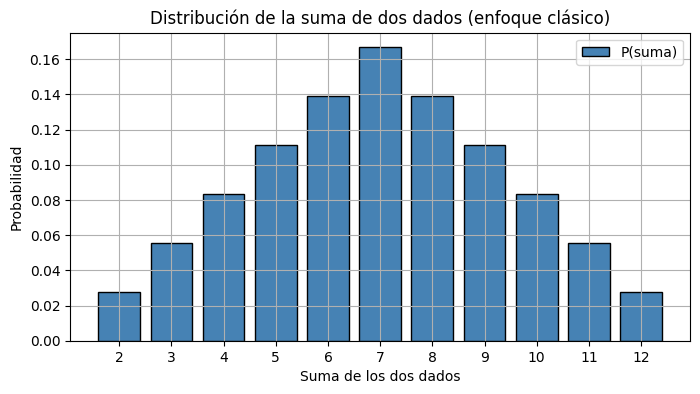

In [5]:
# --- Distribución de la suma de dos dados (enfoque clásico) ---
sumas = {}
for (i, j) in Omega_2dados:
    s = i + j
    sumas[s] = sumas.get(s, 0) + 1   # contamos casos favorables por cada suma

valores = sorted(sumas)
probs = [sumas[s] / len(Omega_2dados) for s in valores]

print("Suma : Probabilidad")
for s, p in zip(valores, probs):
    print(f"  {s:2d} : {p:.4f}")

# Gráfica de la distribución de la suma
plt.figure(figsize=(8, 4))
plt.bar(valores, probs, color='steelblue', edgecolor='black', label='P(suma)')
plt.title('Distribución de la suma de dos dados (enfoque clásico)')
plt.xlabel('Suma de los dos dados')
plt.ylabel('Probabilidad')
plt.xticks(valores)
plt.legend()
plt.show()

In [6]:
# --- Baraja de 52 cartas (enfoque clásico) ---
palos = ['Corazones', 'Diamantes', 'Treboles', 'Picas']
valores_carta = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']
baraja = set(product(valores_carta, palos))
print("Total de cartas en la baraja:", len(baraja))

# Evento: sacar un As
ases = {(v, p) for (v, p) in baraja if v == 'A'}
# Evento: sacar una carta de Corazones
corazones = {(v, p) for (v, p) in baraja if p == 'Corazones'}

print("P(sacar un As)          =", P(ases, baraja))
print("P(sacar Corazones)      =", P(corazones, baraja))
print("P(As de Corazones)      =", P(ases & corazones, baraja))
print("P(As o Corazones)       =", P(ases | corazones, baraja))

Total de cartas en la baraja: 52
P(sacar un As)          = 1/13
P(sacar Corazones)      = 1/4
P(As de Corazones)      = 1/52
P(As o Corazones)       = 4/13


## 6. Enfoque frecuentista

El **enfoque frecuentista** define la probabilidad de un evento como el límite de su
**frecuencia relativa** cuando el número de repeticiones $n$ tiende a infinito:
$$P(A) = \lim_{n \to \infty} \frac{n_A}{n},$$
donde $n_A$ es el número de veces que ocurre $A$ en $n$ repeticiones.

Simulamos el lanzamiento repetido de una moneda justa y observamos cómo la frecuencia
relativa de "Águila" **converge a 0.5** (Ley de los Grandes Números).


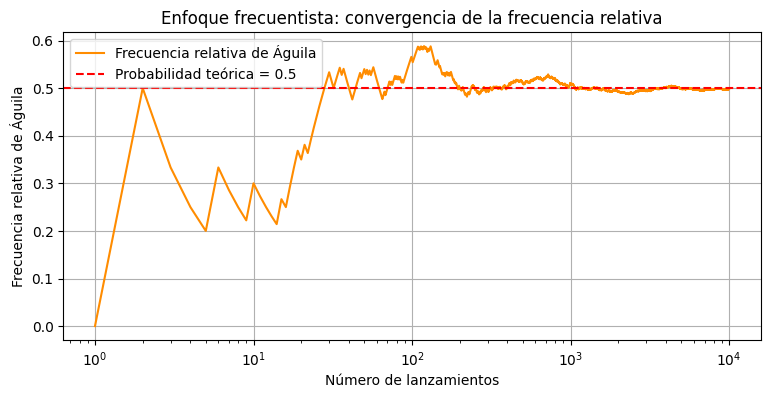

Frecuencia relativa tras 10000 lanzamientos: 0.4987


In [7]:
# Simulamos n lanzamientos de una moneda justa (0 = Sol, 1 = Águila)
n = 10000
lanzamientos = np.random.randint(0, 2, size=n)

# Frecuencia relativa acumulada de Águila
frec_acumulada = np.cumsum(lanzamientos) / np.arange(1, n + 1)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, n + 1), frec_acumulada, color='darkorange',
         label='Frecuencia relativa de Águila')
plt.axhline(0.5, color='red', linestyle='--', label='Probabilidad teórica = 0.5')
plt.title('Enfoque frecuentista: convergencia de la frecuencia relativa')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Frecuencia relativa de Águila')
plt.xscale('log')   # escala logarítmica para apreciar la convergencia
plt.legend()
plt.show()

print(f"Frecuencia relativa tras {n} lanzamientos: {frec_acumulada[-1]:.4f}")

## 7. Enfoque geométrico: estimación de $\pi$ con Monte Carlo

En el **enfoque geométrico** la probabilidad se asocia a una **medida** (longitud, área o
volumen). Si lanzamos un punto al azar de manera uniforme dentro de una región, la
probabilidad de caer en una subregión $A$ es:
$$P(A) = \frac{\text{área}(A)}{\text{área}(\Omega)}.$$

**Estimación de $\pi$:** consideramos el cuadrado $[-1,1]\times[-1,1]$ (área $=4$) y el
círculo de radio 1 inscrito (área $=\pi$). La probabilidad de que un punto uniforme caiga
dentro del círculo es $\pi/4$. Por lo tanto:
$$\pi \approx 4 \cdot \frac{\text{puntos dentro del círculo}}{\text{puntos totales}}.$$


Puntos totales      : 20000
Puntos en el círculo: 15691
Estimación de pi    : 3.13820
Valor real de pi    : 3.14159


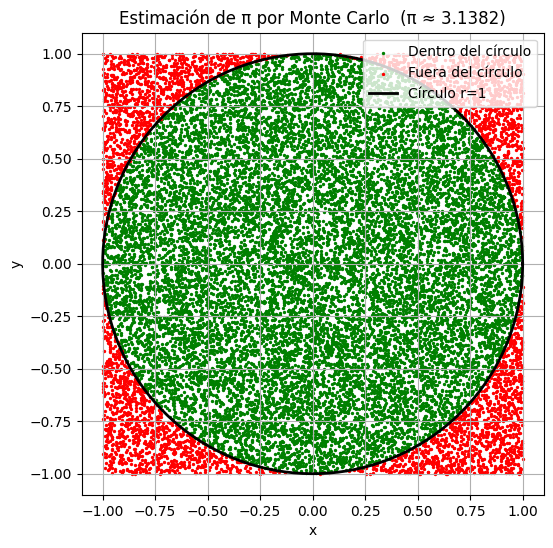

In [8]:
# Método de Monte Carlo para estimar pi
N = 20000
# Generamos N puntos uniformes en el cuadrado [-1,1] x [-1,1]
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# ¿Cada punto cae dentro del círculo de radio 1?
dentro = x**2 + y**2 <= 1
pi_estimado = 4 * np.sum(dentro) / N

print(f"Puntos totales      : {N}")
print(f"Puntos en el círculo: {np.sum(dentro)}")
print(f"Estimación de pi    : {pi_estimado:.5f}")
print(f"Valor real de pi    : {np.pi:.5f}")

# Gráfica de los puntos
plt.figure(figsize=(6, 6))
plt.scatter(x[dentro], y[dentro], s=2, color='green', label='Dentro del círculo')
plt.scatter(x[~dentro], y[~dentro], s=2, color='red', label='Fuera del círculo')
# Dibujamos el círculo teórico
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), color='black', lw=2, label='Círculo r=1')
plt.title(f'Estimación de π por Monte Carlo  (π ≈ {pi_estimado:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.legend(loc='upper right')
plt.show()

## 8. Problema del encuentro

Dos personas acuerdan verse entre las 12:00 y la 1:00 pm. Cada una llega en un instante
**uniforme** dentro de esa hora (independientes) y espera $t$ minutos; si la otra no llega
en ese tiempo, se va. ¿Cuál es la probabilidad de que **se encuentren**?

Sean $X, Y \sim U(0,60)$ los minutos de llegada. Se encuentran si $|X - Y| \le t$.
Geométricamente, la probabilidad es el área de la franja $|x-y|\le t$ dividida entre el
área total del cuadrado $60\times 60$:
$$P(\text{encuentro}) = \frac{60^2 - (60 - t)^2}{60^2} = 1 - \left(\frac{60-t}{60}\right)^2.$$

Comparamos la fórmula teórica con una simulación de Monte Carlo para varios valores de $t$.


 t (min) |   Simulada |    Teórica
----------------------------------
       5 |     0.1596 |     0.1597
      10 |     0.3053 |     0.3056
      15 |     0.4357 |     0.4375
      20 |     0.5584 |     0.5556
      30 |     0.7510 |     0.7500
      45 |     0.9377 |     0.9375


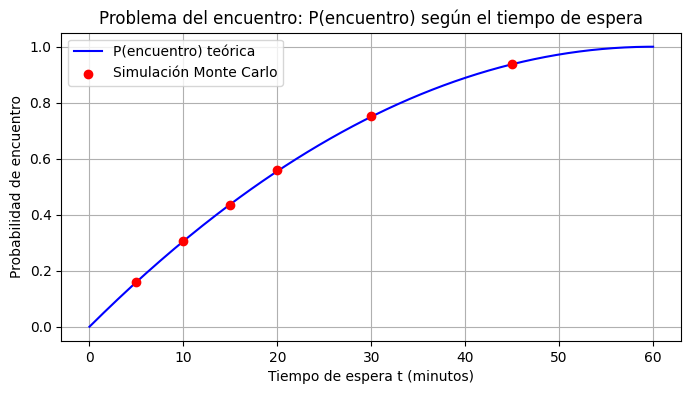

In [9]:
# Simulación del problema del encuentro
def prob_encuentro_sim(t, n=200000):
    "Estima P(encuentro) por Monte Carlo para espera de t minutos."
    X = np.random.uniform(0, 60, n)
    Y = np.random.uniform(0, 60, n)
    return np.mean(np.abs(X - Y) <= t)

def prob_encuentro_teorica(t):
    "Probabilidad teórica (área geométrica)."
    return 1 - ((60 - t) / 60) ** 2

tiempos = [5, 10, 15, 20, 30, 45]
print(f"{'t (min)':>8} | {'Simulada':>10} | {'Teórica':>10}")
print("-" * 34)
sim_vals, teo_vals = [], []
for t in tiempos:
    ps = prob_encuentro_sim(t)
    pt = prob_encuentro_teorica(t)
    sim_vals.append(ps)
    teo_vals.append(pt)
    print(f"{t:>8} | {ps:>10.4f} | {pt:>10.4f}")

# Gráfica comparativa
t_grid = np.linspace(0, 60, 200)
plt.figure(figsize=(8, 4))
plt.plot(t_grid, [prob_encuentro_teorica(t) for t in t_grid],
         color='blue', label='P(encuentro) teórica')
plt.scatter(tiempos, sim_vals, color='red', zorder=5, label='Simulación Monte Carlo')
plt.title('Problema del encuentro: P(encuentro) según el tiempo de espera')
plt.xlabel('Tiempo de espera t (minutos)')
plt.ylabel('Probabilidad de encuentro')
plt.legend()
plt.show()

## 9. Ejemplo del volado (Ley de los Grandes Números)

Un **volado** es el lanzamiento de una moneda. Repetimos el experimento con
$20, 100, 1000$ y $10000$ lanzamientos y observamos cómo la proporción de "Águila"
se **acerca a 0.5** a medida que aumenta el número de lanzamientos. Esto ilustra la
**Ley de los Grandes Números**.


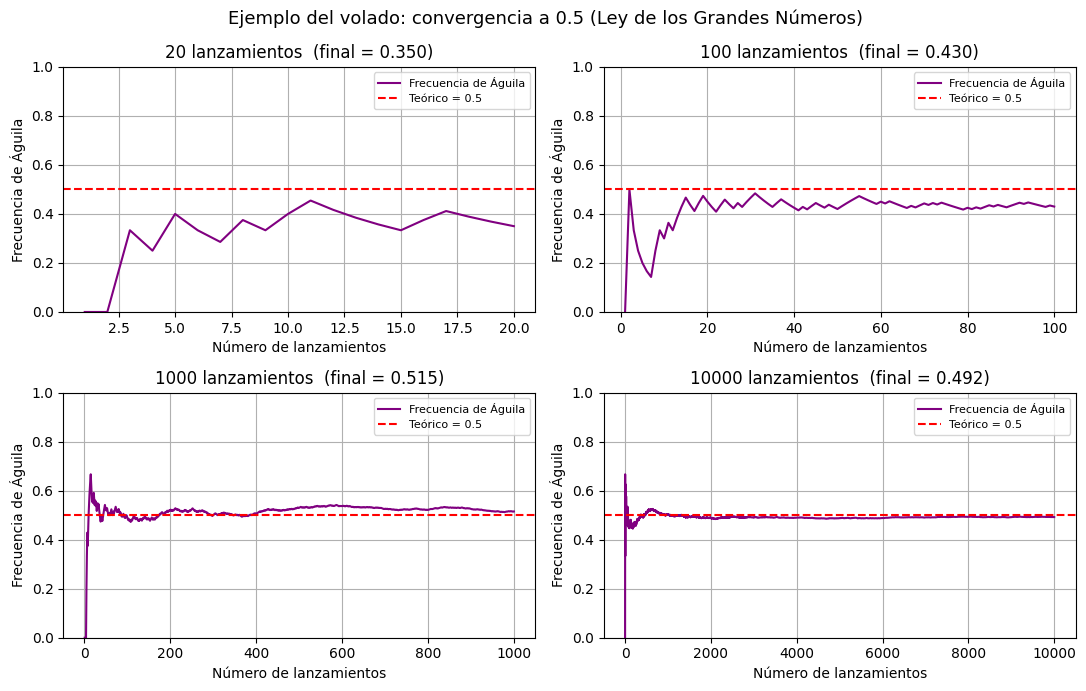

In [10]:
# Ejemplo del volado con distinto número de lanzamientos
tamanios = [20, 100, 1000, 10000]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for ax, m in zip(axes, tamanios):
    volados = np.random.randint(0, 2, size=m)     # 0=Sol, 1=Águila
    frec = np.cumsum(volados) / np.arange(1, m + 1)
    ax.plot(np.arange(1, m + 1), frec, color='purple', label='Frecuencia de Águila')
    ax.axhline(0.5, color='red', linestyle='--', label='Teórico = 0.5')
    ax.set_title(f'{m} lanzamientos  (final = {frec[-1]:.3f})')
    ax.set_xlabel('Número de lanzamientos')
    ax.set_ylabel('Frecuencia de Águila')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

fig.suptitle('Ejemplo del volado: convergencia a 0.5 (Ley de los Grandes Números)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 10. Ejemplo adicional propio: urna con bolas de colores

Proponemos un ejemplo propio. Una **urna** contiene:

- 5 bolas **rojas**,
- 3 bolas **verdes**,
- 2 bolas **azules**.

Extraemos una bola al azar. Calcularemos las probabilidades **teóricas** (enfoque clásico)
y las compararemos con una **simulación** de muchas extracciones (enfoque frecuentista).


Urna: ['Roja', 'Roja', 'Roja', 'Roja', 'Roja', 'Verde', 'Verde', 'Verde', 'Azul', 'Azul'] -> total = 10 bolas

Probabilidades teóricas:
  P(Roja) = 1/2 = 0.500
  P(Verde) = 3/10 = 0.300
  P(Azul) = 1/5 = 0.200

Probabilidades simuladas ( 50000 extracciones):
  P(Roja) ≈ 0.496
  P(Verde) ≈ 0.306
  P(Azul) ≈ 0.197


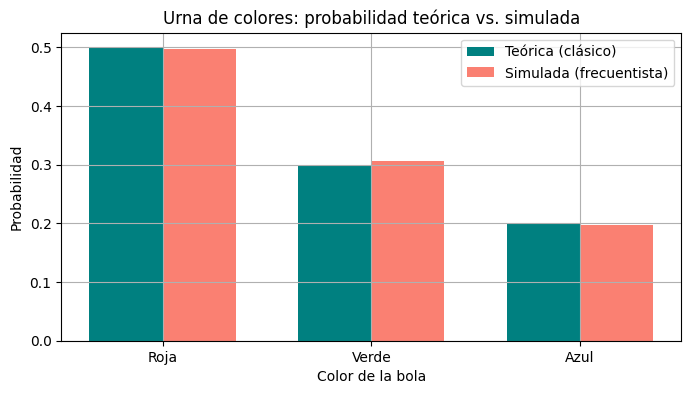

In [11]:
# Composición de la urna
urna = ['Roja'] * 5 + ['Verde'] * 3 + ['Azul'] * 2
total_bolas = len(urna)
print("Urna:", urna, "-> total =", total_bolas, "bolas")

# --- Probabilidades teóricas (enfoque clásico) ---
colores = ['Roja', 'Verde', 'Azul']
prob_teorica = {c: Fraction(urna.count(c), total_bolas) for c in colores}
print("\nProbabilidades teóricas:")
for c in colores:
    print(f"  P({c}) = {prob_teorica[c]} = {float(prob_teorica[c]):.3f}")

# --- Simulación (enfoque frecuentista) ---
n_extracciones = 50000
extracciones = np.random.choice(urna, size=n_extracciones)  # con reemplazo
prob_sim = {c: np.mean(extracciones == c) for c in colores}
print("\nProbabilidades simuladas (", n_extracciones, "extracciones):")
for c in colores:
    print(f"  P({c}) ≈ {prob_sim[c]:.3f}")

# --- Gráfica comparativa ---
x_pos = np.arange(len(colores))
ancho = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x_pos - ancho/2, [float(prob_teorica[c]) for c in colores], ancho,
        color='teal', label='Teórica (clásico)')
plt.bar(x_pos + ancho/2, [prob_sim[c] for c in colores], ancho,
        color='salmon', label='Simulada (frecuentista)')
plt.title('Urna de colores: probabilidad teórica vs. simulada')
plt.xlabel('Color de la bola')
plt.ylabel('Probabilidad')
plt.xticks(x_pos, colores)
plt.legend()
plt.show()

## 11. Conclusión

En este notebook construimos, paso a paso, la noción de **espacio de probabilidad**
$(\Omega, \mathcal{F}, P)$ y sus componentes:

- Definimos el **espacio muestral** y los **eventos**, y operamos con ellos como conjuntos.
- Enunciamos y verificamos numéricamente los **axiomas de Kolmogorov** y la regla de la suma.
- Estudiamos la **probabilidad condicional** y la **independencia** de eventos.
- Comparamos los tres enfoques para asignar probabilidad:
  - **Clásico:** casos favorables entre casos totales (dados y cartas).
  - **Frecuentista:** frecuencia relativa que converge a la probabilidad teórica (moneda y volados).
  - **Geométrico:** razón de áreas, aplicado a la estimación de $\pi$ y al problema del encuentro.
- El **ejemplo del volado** y la **urna de colores** confirman la **Ley de los Grandes Números**:
  al aumentar el número de repeticiones, la frecuencia relativa se aproxima a la probabilidad teórica.

Las simulaciones de Monte Carlo resultaron ser una herramienta poderosa para estimar
probabilidades difíciles de calcular analíticamente y para **verificar** los resultados teóricos.


## 12. Bibliografía

- Rincón, L. (2014). *Introducción a la probabilidad*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2014). *A First Course in Probability* (9.ª ed.). Pearson.
- Mood, A. M., Graybill, F. A. y Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3.ª ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J. y Beaver, B. M. (2010). *Introducción a la probabilidad y estadística* (13.ª ed.). Cengage Learning.
